In [8]:
from scipy.io import loadmat
from collections import Counter
import numpy as np, matplotlib.pyplot as plt

MAT = "../data/raw/Battery_DataSet/Battery_DataSet/B0005.mat"          # <- paste your real path
m = loadmat(MAT, simplify_cells=True)
cycles = m['B0005']['cycle']


print(type(cycles), "with", len(cycles), "cycles")   # a list of cycles
print("one cycle looks like:", cycles[0].keys())      # type, ambient_temperature, time, data
print("inside its data:", cycles[0]['data'].keys())   # the sensor arrays
print("total cycles:", len(cycles), Counter(c['type'] for c in cycles))

<class 'list'> with 616 cycles
one cycle looks like: dict_keys(['type', 'ambient_temperature', 'time', 'data'])
inside its data: dict_keys(['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time'])
total cycles: 616 Counter({'impedance': 278, 'charge': 170, 'discharge': 168})


In [12]:
import pandas as pd
d = cycles[0]['data']          # first cycle's sensors
one_cycle = pd.DataFrame({
    "time":    np.ravel(d['Time']),
    "voltage": np.ravel(d['Voltage_measured']),
    "current": np.ravel(d['Current_measured']),
    "temp":    np.ravel(d['Temperature_measured']),
})
one_cycle.head(20)

,time,voltage,current,temp
0,0.000,3.873017,-0.001201,24.655358
1,2.532,3.479394,-4.030268,24.666480
2,5.500,4.000588,1.512731,24.675394
3,8.344,4.012395,1.509063,24.693865
4,11.125,4.019708,1.511318,24.705069
5,13.891,4.025409,1.512779,24.718140
6,16.672,4.030636,1.511838,24.731144
7,19.500,4.035349,1.510245,24.741290
8,22.282,4.039716,1.507796,24.759011
9,25.063,4.043541,1.507322,24.766891


In [13]:
len(one_cycle)

789

In [24]:
discharge = [c for c in cycles if c['type'] == 'discharge']
lengths = [len(np.ravel(c['data']['Time'])) for c in discharge]
print("first cycle rows:", lengths[0], " last cycle rows:", lengths[-1])

first cycle rows: 197  last cycle rows: 300


In [25]:
d = discharge[0]['data']
tbl = pd.DataFrame({
    "time_s":  np.ravel(d['Time']),
    "voltage": np.ravel(d['Voltage_measured']),
    "current": np.ravel(d['Current_measured']),
    "temp":    np.ravel(d['Temperature_measured']),
})
tbl.iloc[::len(tbl)//8].round(2)     # every Nth row, ~8 rows total

,time_s,voltage,current,temp
0,0.00,4.19,-0.00,24.33
24,435.48,3.79,-2.01,28.23
48,873.58,3.69,-2.01,30.39
72,1314.30,3.61,-2.01,31.60
96,1759.02,3.54,-2.01,32.78
120,2209.42,3.48,-2.01,33.82
144,2666.52,3.43,-2.01,35.17
168,3131.23,3.25,-2.01,37.18
192,3608.59,3.26,-0.00,35.30


In [26]:
print("voltage array length:", np.ravel(d['Voltage_measured']).shape)   # ~197 values
print("capacity array length:", np.ravel(d['Capacity']).shape)          # just 1 value
print("capacity value:", np.ravel(d['Capacity']))

voltage array length: (197,)
capacity array length: (1,)
capacity value: [1.85648742]


In [21]:
import numpy as np
discharge = [c for c in cycles if c['type'] == 'discharge']

for i in [0, 1, 2, len(discharge)//2, -2, -1]:
    d = discharge[i]['data']
    t = np.ravel(d['Time'])
    cap = np.ravel(d['Capacity'])[0]
    print(f"cycle {i:>4}: rows={len(t):>4}  duration={t[-1]:>7.0f}s  "
          f"capacity={cap:.3f}Ah  avg_sample_gap={np.mean(np.diff(t)):.2f}s")

cycle    0: rows= 197  duration=   3690s  capacity=1.856Ah  avg_sample_gap=18.83s
cycle    1: rows= 196  duration=   3672s  capacity=1.846Ah  avg_sample_gap=18.83s
cycle    2: rows= 195  duration=   3652s  capacity=1.835Ah  avg_sample_gap=18.82s
cycle   84: rows= 327  duration=   3067s  capacity=1.538Ah  avg_sample_gap=9.41s
cycle   -2: rows= 298  duration=   2802s  capacity=1.309Ah  avg_sample_gap=9.43s
cycle   -1: rows= 300  duration=   2820s  capacity=1.325Ah  avg_sample_gap=9.43s


In [27]:

# pull the start-timestamp of every discharge step, in file order
times = []
for c in cycles:
    if c['type'] != 'discharge':
        continue
    y, mo, d, h, mi, s = np.ravel(c['time'])[:6]
    times.append(pd.Timestamp(int(y), int(mo), int(d), int(h), int(mi), int(s)))

times = pd.Series(times)
print("number of discharge steps:", len(times))
print("is every step later than the one before it?", times.is_monotonic_increasing)
print("first three timestamps:", list(times[:3]))

number of discharge steps: 168
is every step later than the one before it? True
first three timestamps: [Timestamp('2008-04-02 15:25:41'), Timestamp('2008-04-02 19:43:48'), Timestamp('2008-04-03 00:01:06')]


## Plotting!!

In [28]:
def curve(step, field):
    """pull one sensor array out of a step's data bag."""
    return np.ravel(step['data'][field]).astype(float)

def start_time(step):
    y, mo, d, h, mi, s = np.ravel(step['time'])[:6]
    return pd.Timestamp(int(y), int(mo), int(d), int(h), int(mi), int(s))

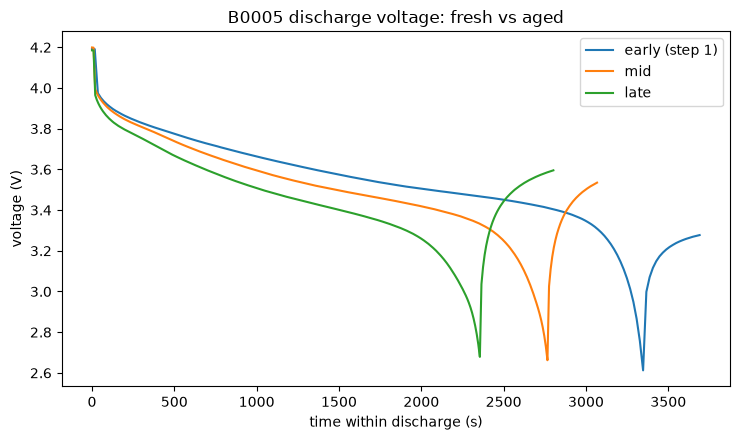

In [29]:
discharge = sorted([c for c in cycles if c['type']=='discharge'], key=start_time)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, i in [("early (step 1)", 0), ("mid", len(discharge)//2), ("late", len(discharge)-2)]:
    step = discharge[i]
    ax.plot(curve(step,'Time'), curve(step,'Voltage_measured'), label=label)
ax.set_xlabel("time within discharge (s)"); ax.set_ylabel("voltage (V)")
ax.set_title("B0005 discharge voltage: fresh vs aged")
ax.legend(); plt.tight_layout(); plt.show()

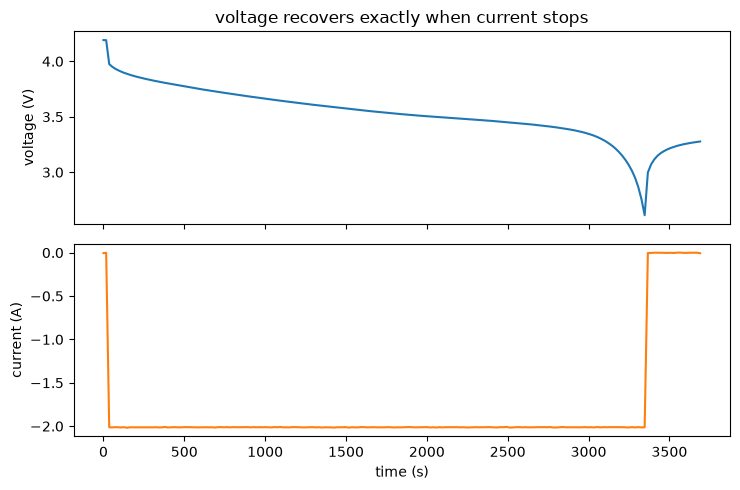

In [30]:
step = discharge[0]
t = curve(step,'Time'); v = curve(step,'Voltage_measured'); i = curve(step,'Current_measured')

fig, ax = plt.subplots(2,1, figsize=(7.5,5), sharex=True)
ax[0].plot(t, v); ax[0].set_ylabel("voltage (V)")
ax[1].plot(t, i, color="tab:orange"); ax[1].set_ylabel("current (A)"); ax[1].set_xlabel("time (s)")
ax[0].set_title("voltage recovers exactly when current stops")
plt.tight_layout(); plt.show()

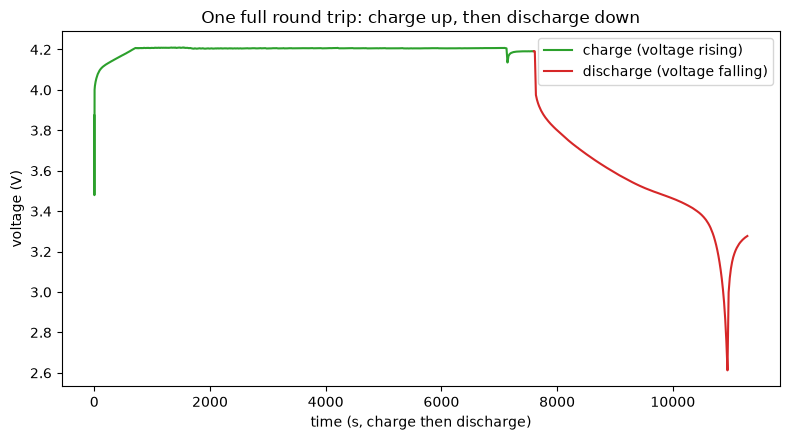

In [31]:
steps_sorted = sorted(cycles, key=start_time)   # ALL steps, in time order

# find the first charge, then the first discharge that comes after it
ci = next(i for i,s in enumerate(steps_sorted) if s['type']=='charge')
di = next(i for i in range(ci+1, len(steps_sorted)) if steps_sorted[i]['type']=='discharge')
chg, dis = steps_sorted[ci], steps_sorted[di]

fig, ax = plt.subplots(figsize=(8, 4.5))
# lay them end to end on a shared time axis by offsetting the discharge
t_chg = curve(chg,'Time')
t_dis = curve(dis,'Time') + t_chg[-1]      # start discharge where charge ended
ax.plot(t_chg, curve(chg,'Voltage_measured'), color="tab:green", label="charge (voltage rising)")
ax.plot(t_dis, curve(dis,'Voltage_measured'), color="tab:red",   label="discharge (voltage falling)")
ax.set_xlabel("time (s, charge then discharge)"); ax.set_ylabel("voltage (V)")
ax.set_title("One full round trip: charge up, then discharge down")
ax.legend(); plt.tight_layout(); plt.show()

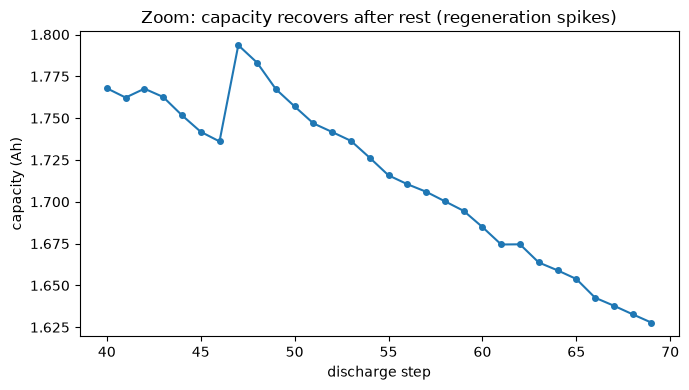

In [32]:
caps = [np.ravel(s['data']['Capacity'])[0] for s in discharge]
plt.figure(figsize=(7,4))
plt.plot(range(40,70), caps[40:70], marker='o', ms=4)
plt.xlabel("discharge step"); plt.ylabel("capacity (Ah)")
plt.title("Zoom: capacity recovers after rest (regeneration spikes)")
plt.tight_layout(); plt.show()